# Modélisation Textuelle - TF-IDF

## Objectif
Classification des produits Rakuten en utilisant TF-IDF (Term Frequency-Inverse Document Frequency) comme représentation vectorielle des textes, combiné avec différents classifieurs classiques.

## Approche
1. **Vectorisation TF-IDF** : Transformation des textes en vecteurs numériques
2. **Classifieurs testés** :
   - Régression Logistique
   - SVM (Support Vector Machine)
   - Random Forest
   - Naive Bayes
3. **Évaluation** : Métriques de classification multi-classes (accuracy, F1-score, confusion matrix)


## 1. Importation des bibliothèques


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn pour TF-IDF et classifieurs
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

# Pour sauvegarder les modèles
import joblib
import os

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Bibliothèques importées")


✅ Bibliothèques importées


## 2. Chargement et préparation des données


In [2]:
# Chargement des données
X_train = pd.read_csv('X_train_update.csv')
Y_train = pd.read_csv('Y_train_CVw08PX.csv')
X_test = pd.read_csv('X_test_update.csv')

print(f"Taille X_train : {X_train.shape}")
print(f"Taille Y_train : {Y_train.shape}")
print(f"Taille X_test : {X_test.shape}")

# Fusion des données d'entraînement
train_data = pd.merge(X_train, Y_train, left_index=True, right_index=True)
print(f"\nTaille train_data après fusion : {train_data.shape}")


Taille X_train : (84916, 5)
Taille Y_train : (84916, 2)
Taille X_test : (13812, 5)

Taille train_data après fusion : (84916, 7)


## 3. Nettoyage et préparation du texte


In [3]:
# Fonction de nettoyage (identique à celle du notebook d'exploration)
import re

def nettoyer_texte(texte):
    """Nettoie le texte en supprimant les balises HTML et en remplaçant les entités HTML"""
    if pd.isna(texte) or texte == 'nan':
        return ''
    texte = str(texte)
    # Supprimer les balises HTML
    texte = re.sub(r'<[^>]+>', '', texte)
    # Remplacer les entités HTML
    texte = texte.replace('&nbsp;', ' ')
    texte = texte.replace('&amp;', '&')
    texte = texte.replace('&lt;', '<')
    texte = texte.replace('&gt;', '>')
    texte = texte.replace('&quot;', '"')
    texte = texte.replace('&#39;', "'")
    texte = texte.replace('&eacute;', 'é')
    texte = texte.replace('&egrave;', 'è')
    texte = texte.replace('&ecirc;', 'ê')
    texte = texte.replace('&agrave;', 'à')
    # Normaliser les espaces
    texte = re.sub(r'\s+', ' ', texte)
    texte = texte.strip()
    return texte

# Appliquer le nettoyage
print("Nettoyage des textes...")
train_data['designation_clean'] = train_data['designation'].apply(nettoyer_texte)
train_data['description_clean'] = train_data['description'].apply(nettoyer_texte)

# Créer le texte complet
train_data['texte_complet'] = train_data['designation_clean'] + ' ' + train_data['description_clean']
train_data['texte_complet'] = train_data['texte_complet'].str.strip()

# Faire de même pour X_test
X_test['designation_clean'] = X_test['designation'].apply(nettoyer_texte)
X_test['description_clean'] = X_test['description'].apply(nettoyer_texte)
X_test['texte_complet'] = X_test['designation_clean'] + ' ' + X_test['description_clean']
X_test['texte_complet'] = X_test['texte_complet'].str.strip()

print(f"✅ Nettoyage terminé")
print(f"Textes vides dans train : {(train_data['texte_complet'] == '').sum()}")
print(f"Textes vides dans test : {(X_test['texte_complet'] == '').sum()}")


Nettoyage des textes...
✅ Nettoyage terminé
Textes vides dans train : 0
Textes vides dans test : 0


## 4. Vectorisation TF-IDF


In [4]:
# Préparer les données
X_text = train_data['texte_complet'].fillna('')
y = train_data['prdtypecode']

# Paramètres TF-IDF
max_features = 10000  # Nombre maximum de features (mots)
ngram_range = (1, 2)  # Unigrammes et bigrammes
min_df = 2  # Fréquence minimale d'un mot dans les documents
max_df = 0.95  # Fréquence maximale (pour éviter les mots trop communs)

print("Création du vectoriseur TF-IDF...")
print(f"Paramètres : max_features={max_features}, ngram_range={ngram_range}, min_df={min_df}, max_df={max_df}")

# Créer et ajuster le vectoriseur TF-IDF
vectorizer = TfidfVectorizer(
    max_features=max_features,
    ngram_range=ngram_range,
    min_df=min_df,
    max_df=max_df,
    lowercase=True,
    strip_accents='unicode',
    stop_words=None  # On peut ajouter des stop words français si nécessaire
)

# Vectoriser les données d'entraînement
X_tfidf = vectorizer.fit_transform(X_text)
print(f"\n✅ Vectorisation terminée")
print(f"Shape de X_tfidf : {X_tfidf.shape}")
print(f"Nombre de features (mots) : {len(vectorizer.get_feature_names_out())}")

# Vectoriser les données de test
X_test_text = X_test['texte_complet'].fillna('')
X_test_tfidf = vectorizer.transform(X_test_text)
print(f"Shape de X_test_tfidf : {X_test_tfidf.shape}")


Création du vectoriseur TF-IDF...
Paramètres : max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95

✅ Vectorisation terminée
Shape de X_tfidf : (84916, 10000)
Nombre de features (mots) : 10000
Shape de X_test_tfidf : (13812, 10000)


## 5. Division train/validation


In [5]:
# Division train/validation (80/20)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train : {X_train_split.shape[0]}")
print(f"Taille validation : {X_val_split.shape[0]}")
print(f"Nombre de classes : {len(np.unique(y))}")


Taille train : 67932
Taille validation : 16984
Nombre de classes : 27


## 6. Modélisation avec différents classifieurs


In [6]:
# Dictionnaire pour stocker les résultats
results = {}

# Fonction pour évaluer un modèle
def evaluer_modele(model, X_train, y_train, X_val, y_val, nom_modele):
    """Entraîne et évalue un modèle"""
    print(f"\n{'='*60}")
    print(f"Modèle : {nom_modele}")
    print(f"{'='*60}")
    
    # Entraînement
    print("Entraînement en cours...")
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_val)
    
    # Métriques
    accuracy = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    
    print(f"\nMétriques sur la validation :")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  F1-score (macro) : {f1_macro:.4f}")
    print(f"  F1-score (weighted) : {f1_weighted:.4f}")
    print(f"  Precision (weighted) : {precision:.4f}")
    print(f"  Recall (weighted) : {recall:.4f}")
    
    # Stocker les résultats
    results[nom_modele] = {
        'model': model,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision': precision,
        'recall': recall,
        'y_pred': y_pred
    }
    
    return model, results[nom_modele]


### 6.1 Régression Logistique


In [7]:
# Régression Logistique avec class_weight pour gérer le déséquilibre
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Pour gérer le déséquilibre des classes
    n_jobs=-1
)

lr_model, lr_results = evaluer_modele(
    lr_model, X_train_split, y_train_split, X_val_split, y_val_split, 
    "Régression Logistique"
)



Modèle : Régression Logistique
Entraînement en cours...

Métriques sur la validation :
  Accuracy : 0.7775
  F1-score (macro) : 0.7602
  F1-score (weighted) : 0.7793
  Precision (weighted) : 0.7883
  Recall (weighted) : 0.7775


### 6.2 SVM (Support Vector Machine)


In [8]:
# SVM avec kernel linéaire (plus rapide pour les grandes matrices creuses)
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42,
    probability=True  # Pour avoir les probabilités
)

svm_model, svm_results = evaluer_modele(
    svm_model, X_train_split, y_train_split, X_val_split, y_val_split,
    "SVM (Linear)"
)



Modèle : SVM (Linear)
Entraînement en cours...

Métriques sur la validation :
  Accuracy : 0.7873
  F1-score (macro) : 0.7746
  F1-score (weighted) : 0.7906
  Precision (weighted) : 0.8015
  Recall (weighted) : 0.7873


### 6.3 Random Forest


In [9]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model, rf_results = evaluer_modele(
    rf_model, X_train_split, y_train_split, X_val_split, y_val_split,
    "Random Forest"
)



Modèle : Random Forest
Entraînement en cours...

Métriques sur la validation :
  Accuracy : 0.7145
  F1-score (macro) : 0.7176
  F1-score (weighted) : 0.7332
  Precision (weighted) : 0.7776
  Recall (weighted) : 0.7145


### 6.4 Naive Bayes Multinomial


In [10]:
# Naive Bayes Multinomial (adapté aux données TF-IDF)
nb_model = MultinomialNB(alpha=1.0)

nb_model, nb_results = evaluer_modele(
    nb_model, X_train_split, y_train_split, X_val_split, y_val_split,
    "Naive Bayes Multinomial"
)



Modèle : Naive Bayes Multinomial
Entraînement en cours...

Métriques sur la validation :
  Accuracy : 0.7143
  F1-score (macro) : 0.6772
  F1-score (weighted) : 0.7034
  Precision (weighted) : 0.7226
  Recall (weighted) : 0.7143


## 7. Comparaison des modèles



COMPARAISON DES MODÈLES
                 Modèle  Accuracy  F1-score (macro)  F1-score (weighted)  Precision (weighted)  Recall (weighted)
           SVM (Linear)  0.787270          0.774563             0.790635              0.801539           0.787270
  Régression Logistique  0.777496          0.760160             0.779254              0.788283           0.777496
          Random Forest  0.714496          0.717619             0.733190              0.777580           0.714496
Naive Bayes Multinomial  0.714260          0.677173             0.703397              0.722551           0.714260


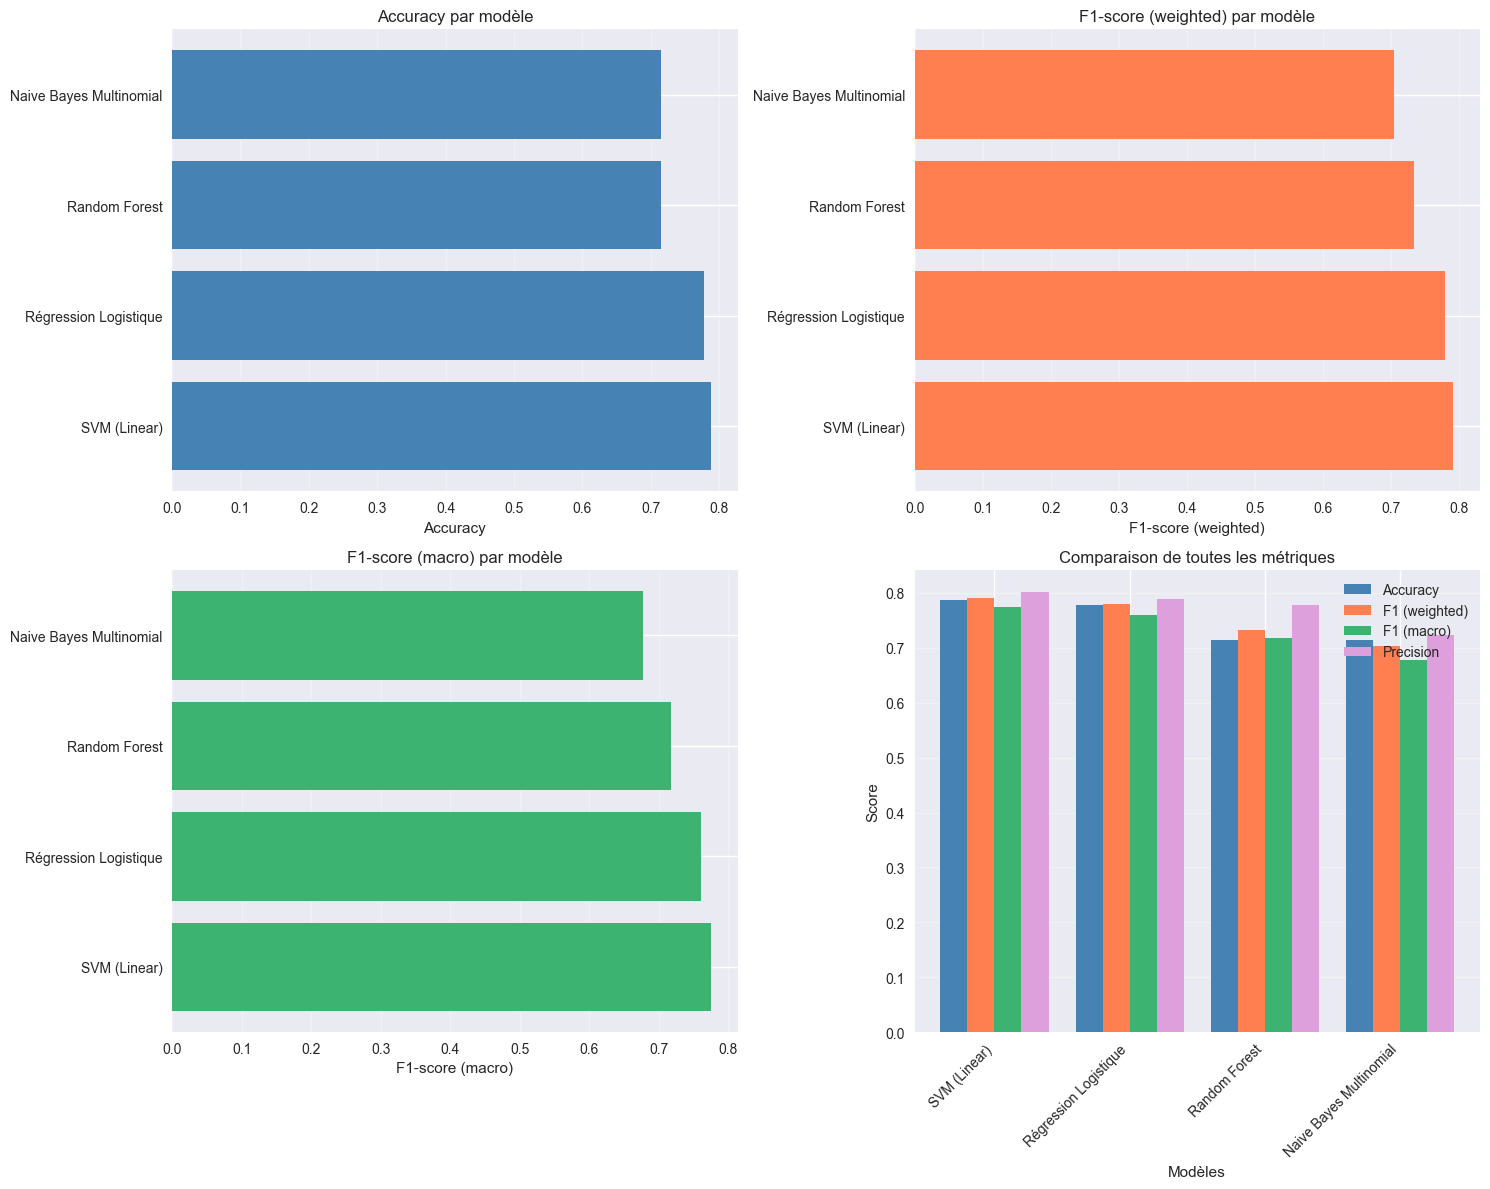


✅ Graphique sauvegardé : figures/comparison_tfidf_models.pdf


In [11]:
# Créer un DataFrame avec les résultats
comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1-score (macro)': [r['f1_macro'] for r in results.values()],
    'F1-score (weighted)': [r['f1_weighted'] for r in results.values()],
    'Precision (weighted)': [r['precision'] for r in results.values()],
    'Recall (weighted)': [r['recall'] for r in results.values()]
})

comparison_df = comparison_df.sort_values('F1-score (weighted)', ascending=False)
print("\n" + "="*80)
print("COMPARAISON DES MODÈLES")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique 1 : Accuracy
axes[0, 0].barh(comparison_df['Modèle'], comparison_df['Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy par modèle')
axes[0, 0].grid(axis='x', alpha=0.3)

# Graphique 2 : F1-score (weighted)
axes[0, 1].barh(comparison_df['Modèle'], comparison_df['F1-score (weighted)'], color='coral')
axes[0, 1].set_xlabel('F1-score (weighted)')
axes[0, 1].set_title('F1-score (weighted) par modèle')
axes[0, 1].grid(axis='x', alpha=0.3)

# Graphique 3 : F1-score (macro)
axes[1, 0].barh(comparison_df['Modèle'], comparison_df['F1-score (macro)'], color='mediumseagreen')
axes[1, 0].set_xlabel('F1-score (macro)')
axes[1, 0].set_title('F1-score (macro) par modèle')
axes[1, 0].grid(axis='x', alpha=0.3)

# Graphique 4 : Toutes les métriques
x = np.arange(len(comparison_df))
width = 0.2
axes[1, 1].bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
axes[1, 1].bar(x - 0.5*width, comparison_df['F1-score (weighted)'], width, label='F1 (weighted)', color='coral')
axes[1, 1].bar(x + 0.5*width, comparison_df['F1-score (macro)'], width, label='F1 (macro)', color='mediumseagreen')
axes[1, 1].bar(x + 1.5*width, comparison_df['Precision (weighted)'], width, label='Precision', color='plum')
axes[1, 1].set_xlabel('Modèles')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Comparaison de toutes les métriques')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_df['Modèle'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/comparison_tfidf_models.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Graphique sauvegardé : figures/comparison_tfidf_models.pdf")


## 8. Matrice de confusion du meilleur modèle


Meilleur modèle : SVM (Linear)
F1-score (weighted) : 0.7906


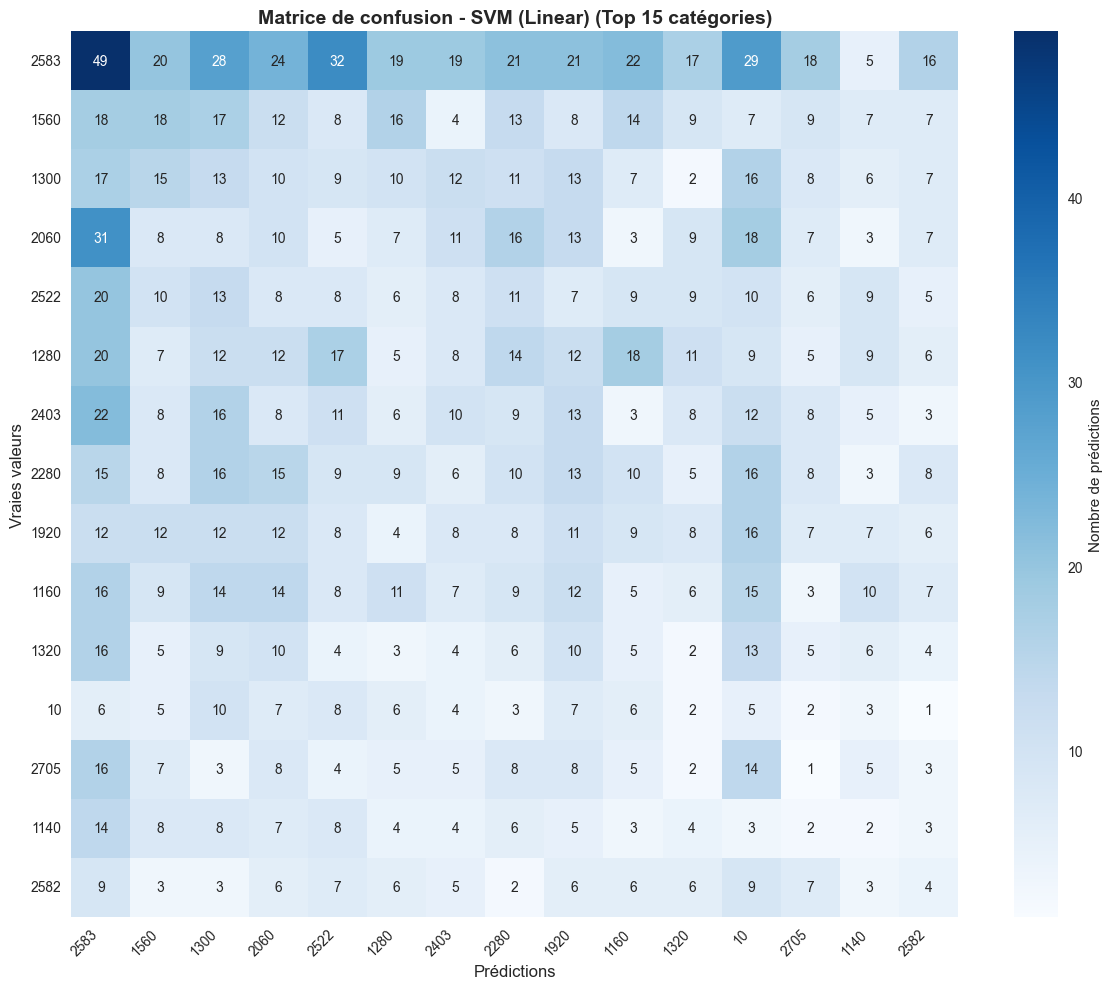

✅ Matrice de confusion sauvegardée : figures/confusion_matrix_tfidf_best.pdf

RAPPORT DE CLASSIFICATION DÉTAILLÉ
              precision    recall  f1-score   support

          10       0.37      0.65      0.47       623
          40       0.64      0.61      0.62       502
          50       0.79      0.82      0.81       336
          60       0.89      0.86      0.88       166
        1140       0.70      0.78      0.73       534
        1160       0.93      0.87      0.90       791
        1180       0.45      0.59      0.51       153
        1280       0.74      0.51      0.60       974
        1281       0.59      0.55      0.57       414
        1300       0.84      0.91      0.87      1009
        1301       0.90      0.91      0.91       161
        1302       0.77      0.77      0.77       498
        1320       0.75      0.78      0.77       648
        1560       0.85      0.80      0.82      1015
        1920       0.88      0.92      0.90       861
        1940       0.7

In [12]:
# Identifier le meilleur modèle (basé sur F1-score weighted)
meilleur_modele_nom = comparison_df.iloc[0]['Modèle']
meilleur_modele = results[meilleur_modele_nom]['model']
y_pred_meilleur = results[meilleur_modele_nom]['y_pred']

print(f"Meilleur modèle : {meilleur_modele_nom}")
print(f"F1-score (weighted) : {results[meilleur_modele_nom]['f1_weighted']:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_val_split, y_pred_meilleur)

# Visualisation de la matrice de confusion (top 15 catégories)
top_categories = y.value_counts().head(15).index
mask_train = y_val_split.isin(top_categories)
mask_pred = pd.Series(y_pred_meilleur).isin(top_categories)
mask = mask_train & mask_pred

y_val_top = y_val_split[mask]
y_pred_top = pd.Series(y_pred_meilleur)[mask]

cm_top = confusion_matrix(y_val_top, y_pred_top, labels=top_categories)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues', 
            xticklabels=top_categories, yticklabels=top_categories,
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de confusion - {meilleur_modele_nom} (Top 15 catégories)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vraies valeurs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_tfidf_best.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Matrice de confusion sauvegardée : figures/confusion_matrix_tfidf_best.pdf")

# Rapport de classification détaillé
print("\n" + "="*80)
print("RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*80)
print(classification_report(y_val_split, y_pred_meilleur))


## 9. Entraînement sur toutes les données et prédictions sur le test


In [13]:
# Entraîner le meilleur modèle sur toutes les données d'entraînement
print(f"Entraînement du meilleur modèle ({meilleur_modele_nom}) sur toutes les données...")

# Réentraîner sur toutes les données
meilleur_modele_final = type(meilleur_modele)(**meilleur_modele.get_params())
meilleur_modele_final.fit(X_tfidf, y)

print("✅ Modèle entraîné sur toutes les données")

# Prédictions sur le test
print("\nGénération des prédictions sur X_test...")
y_test_pred = meilleur_modele_final.predict(X_test_tfidf)

print(f"✅ Prédictions générées : {len(y_test_pred)} prédictions")
print(f"Distribution des prédictions :")
print(pd.Series(y_test_pred).value_counts().head(10))


Entraînement du meilleur modèle (SVM (Linear)) sur toutes les données...
✅ Modèle entraîné sur toutes les données

Génération des prédictions sur X_test...
✅ Prédictions générées : 13812 prédictions
Distribution des prédictions :
2583    1593
10       950
1300     841
2522     829
1560     734
2060     724
2280     724
1920     712
1160     630
2403     627
Name: count, dtype: int64


## 10. Sauvegarde des résultats


In [14]:
# Créer le dossier pour sauvegarder les modèles
os.makedirs('models', exist_ok=True)
os.makedirs('output', exist_ok=True)

# Sauvegarder le vectoriseur TF-IDF
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
print("✅ Vectoriseur TF-IDF sauvegardé : models/tfidf_vectorizer.pkl")

# Sauvegarder le meilleur modèle
joblib.dump(meilleur_modele_final, f'models/tfidf_{meilleur_modele_nom.lower().replace(" ", "_")}.pkl')
print(f"✅ Modèle sauvegardé : models/tfidf_{meilleur_modele_nom.lower().replace(' ', '_')}.pkl")

# Sauvegarder les prédictions
predictions_df = pd.DataFrame({
    'productid': X_test['productid'],
    'prdtypecode': y_test_pred
})
predictions_df.to_csv('output/predictions_tfidf.csv', index=False)
print("✅ Prédictions sauvegardées : output/predictions_tfidf.csv")

# Sauvegarder les résultats de comparaison
comparison_df.to_csv('output/comparison_tfidf_models.csv', index=False)
print("✅ Résultats de comparaison sauvegardés : output/comparison_tfidf_models.csv")

print("\n" + "="*80)
print("RÉSUMÉ FINAL")
print("="*80)
print(f"Meilleur modèle : {meilleur_modele_nom}")
print(f"  - Accuracy : {results[meilleur_modele_nom]['accuracy']:.4f}")
print(f"  - F1-score (weighted) : {results[meilleur_modele_nom]['f1_weighted']:.4f}")
print(f"  - F1-score (macro) : {results[meilleur_modele_nom]['f1_macro']:.4f}")
print(f"\n✅ Tous les fichiers ont été sauvegardés avec succès !")


✅ Vectoriseur TF-IDF sauvegardé : models/tfidf_vectorizer.pkl
✅ Modèle sauvegardé : models/tfidf_svm_(linear).pkl
✅ Prédictions sauvegardées : output/predictions_tfidf.csv
✅ Résultats de comparaison sauvegardés : output/comparison_tfidf_models.csv

RÉSUMÉ FINAL
Meilleur modèle : SVM (Linear)
  - Accuracy : 0.7873
  - F1-score (weighted) : 0.7906
  - F1-score (macro) : 0.7746

✅ Tous les fichiers ont été sauvegardés avec succès !
